<a href="https://colab.research.google.com/github/ayeshanoorqureshi111-coder/Image-Classification/blob/main/Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2032s 12us/step
Training Images : (50000, 32, 32, 3)
Testing Images  : (10000, 32, 32, 3)


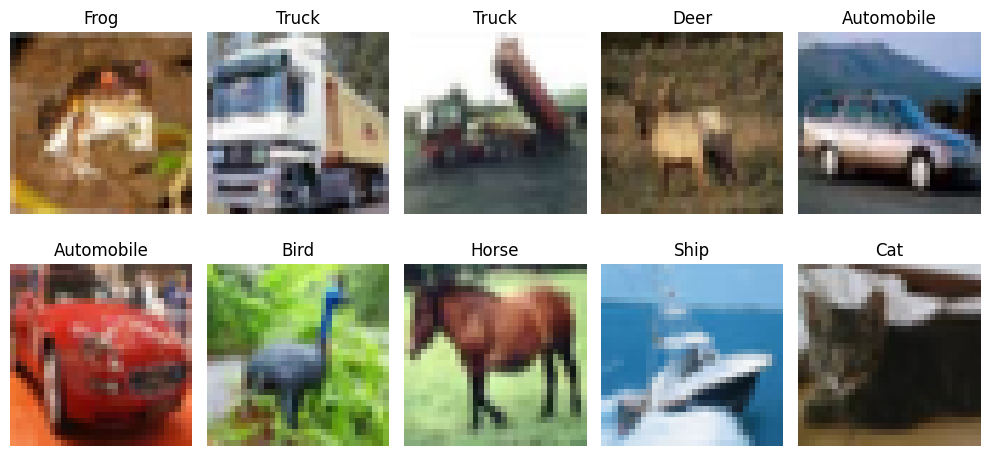

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 89ms/step - accuracy: 0.3574 - loss: 1.7320 - val_accuracy: 0.4804 - val_loss: 1.4325
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 88ms/step - accuracy: 0.4978 - loss: 1.3944 - val_accuracy: 0.5450 - val_loss: 1.2485
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 90ms/step - accuracy: 0.5543 - loss: 1.2562 - val_accuracy: 0.6012 - val_loss: 1.1273
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 86ms/step - accuracy: 0.5911 - loss: 1.1551 - val_accuracy: 0.6135 - val_loss: 1.0967
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 86ms/step - accuracy: 0.6179 - loss: 1.0844 - val_accuracy: 0.6368 - val_loss: 1.0389
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 86ms/step - accuracy: 0.6448 - loss: 1.0121 - val_accuracy: 0.6599 - val_loss: 0.9684
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 84s 89ms/step - accuracy: 0.6639 - loss: 0.9596 - val_accuracy: 0.6754 - val_loss: 0.9438
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.6836 - loss: 0.9092

In [ ]:
# ====================================================
# PROJECT 3: IMAGE CLASSIFICATION USING CNN
# Google Colab - Complete Code
# ====================================================

# Import Libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# ====================================================
# Load CIFAR-10 Dataset
# ====================================================

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("Training Images :", X_train.shape)
print("Testing Images  :", X_test.shape)

# Class Names
class_names = [
    'Airplane',
    'Automobile',
    'Bird',
    'Cat',
    'Deer',
    'Dog',
    'Frog',
    'Horse',
    'Ship',
    'Truck'
]

# ====================================================
# Normalize the Images
# ====================================================

X_train = X_train / 255.0
X_test = X_test / 255.0

# ====================================================
# Display Sample Images
# ====================================================

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

# ====================================================
# Build CNN Model
# ====================================================

model = Sequential()

# First Convolution Layer
model.add(Conv2D(32, (3,3),
                 activation='relu',
                 input_shape=(32,32,3)))
model.add(MaxPooling2D((2,2)))

# Second Convolution Layer
model.add(Conv2D(64, (3,3),
                 activation='relu'))
model.add(MaxPooling2D((2,2)))

# Third Convolution Layer
model.add(Conv2D(64, (3,3),
                 activation='relu'))

# Flatten Layer
model.add(Flatten())

# Dense Layers
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(10, activation='softmax'))

# Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model Summary
model.summary()

# ====================================================
# Train the Model
# ====================================================

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

# ====================================================
# Evaluate the Model
# ====================================================

loss, accuracy = model.evaluate(X_test, y_test)

print("\n===================================")
print("Test Accuracy :", round(accuracy*100,2), "%")
print("Test Loss     :", round(loss,4))
print("===================================\n")

# ====================================================
# Plot Accuracy Graph
# ====================================================

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'],
         label='Training Accuracy')

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model Accuracy")
plt.legend()
plt.show()

# ====================================================
# Plot Loss Graph
# ====================================================

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'],
         label='Training Loss')

plt.plot(history.history['val_loss'],
         label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model Loss")
plt.legend()
plt.show()

# ====================================================
# Make Predictions
# ====================================================

predictions = model.predict(X_test)

predicted_labels = np.argmax(predictions, axis=1)

# ====================================================
# Classification Report
# ====================================================

print("Classification Report:\n")

print(
    classification_report(
        y_test,
        predicted_labels,
        target_names=class_names
    )
)

# ====================================================
# Confusion Matrix
# ====================================================

cm = confusion_matrix(
    y_test,
    predicted_labels
)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ====================================================
# Display Predictions on Images
# ====================================================

plt.figure(figsize=(12,6))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i])
    plt.title(
        "Pred: " +
        class_names[predicted_labels[i]]
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

# ====================================================
# Project Completed
# ====================================================

print("\n========================================")
print("IMAGE CLASSIFICATION PROJECT COMPLETED")
print("Dataset : CIFAR-10")
print("Model   : Convolutional Neural Network")
print("Classes : 10 Image Categories")
print("========================================")